# Doubt triage using Machine Learning

The objective of this notebook is to build a machine learning model that automatically classifies questions into different quality categories based on their content.

The model uses Stack Overflow questions dataset containing titles and question bodies to predict the moderation outcome of a question. This system can assist developer communities by automatically identifying high-quality and low-quality questions, and improving content management and reducing manual effort.

In [1]:
# importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

# 1. Dataset

In [2]:
df = pd.read_csv("../datasets/doubt-triage/train.csv")

df.head()

,Id,Title,Body,Tags,CreationDate,Y
0,34552656,Java: Repeat Task Every Random Seconds,<p>I'm already familiar with repeating tasks e...,<java><repeat>,2016-01-01 00:21:59,LQ_CLOSE
1,34553034,Why are Java Optionals immutable?,<p>I'd like to understand why Java 8 Optionals...,<java><optional>,2016-01-01 02:03:20,HQ
2,34553174,Text Overlay Image with Darkened Opacity React...,<p>I am attempting to overlay a title over an ...,<javascript><image><overlay><react-native><opa...,2016-01-01 02:48:24,HQ
3,34553318,Why ternary operator in swift is so picky?,"<p>The question is very simple, but I just cou...",<swift><operators><whitespace><ternary-operato...,2016-01-01 03:30:17,HQ
4,34553755,hide/show fab with scale animation,<p>I'm using custom floatingactionmenu. I need...,<android><material-design><floating-action-but...,2016-01-01 05:21:48,HQ


In [3]:
df.shape

df.info()

df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            45000 non-null  int64
 1   Title         45000 non-null  str  
 2   Body          45000 non-null  str  
 3   Tags          45000 non-null  str  
 4   CreationDate  45000 non-null  str  
 5   Y             45000 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.1 MB


,Id,Title,Body,Tags,CreationDate,Y
count,4.500000e+04,45000,45000,45000,45000,45000
unique,NaN,44996,45000,25676,44990,3
top,NaN,Regular expression,<p>I'm already familiar with repeating tasks e...,<python>,2016-01-06 08:52:17,LQ_CLOSE
freq,NaN,3,1,798,2,15000
mean,4.575616e+07,NaN,NaN,NaN,NaN,NaN
std,7.120035e+06,NaN,NaN,NaN,NaN,NaN
min,3.455266e+07,NaN,NaN,NaN,NaN,NaN
25%,3.973593e+07,NaN,NaN,NaN,NaN,NaN
50%,4.503563e+07,NaN,NaN,NaN,NaN,NaN
75%,5.125584e+07,NaN,NaN,NaN,NaN,NaN


In [4]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 45000
Columns : 6


# 2. Exploratory Data Analysis

In [5]:
# dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            45000 non-null  int64
 1   Title         45000 non-null  str  
 2   Body          45000 non-null  str  
 3   Tags          45000 non-null  str  
 4   CreationDate  45000 non-null  str  
 5   Y             45000 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.1 MB


In [6]:
# statistic summary

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,45000.0,NaN,NaN,NaN,45756157.363911,7120034.515324,34552656.0,39735929.5,45035634.5,51255844.0,60468018.0
Title,45000,44996,Regular expression,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Body,45000,45000,<p>I'm already familiar with repeating tasks e...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tags,45000,25676,<python>,798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreationDate,45000,44990,2016-01-06 08:52:17,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y,45000,3,LQ_CLOSE,15000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# missing value check

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
Id,0,0.0
Title,0,0.0
Body,0,0.0
Tags,0,0.0
CreationDate,0,0.0
Y,0,0.0


### Observation :

There are no missing values, no need to handle missing values separately.

In [8]:
# duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Observation :

There are no duplicate rows, no need of deleting any duplicate rows.

In [9]:
# target distribution

df["Y"].value_counts()

Y
LQ_CLOSE    15000
HQ          15000
LQ_EDIT     15000
Name: count, dtype: int64

In [10]:
# Question length

df["title_length"] = df["Title"].fillna("").str.len()

df["body_length"] = df["Body"].fillna("").str.len()

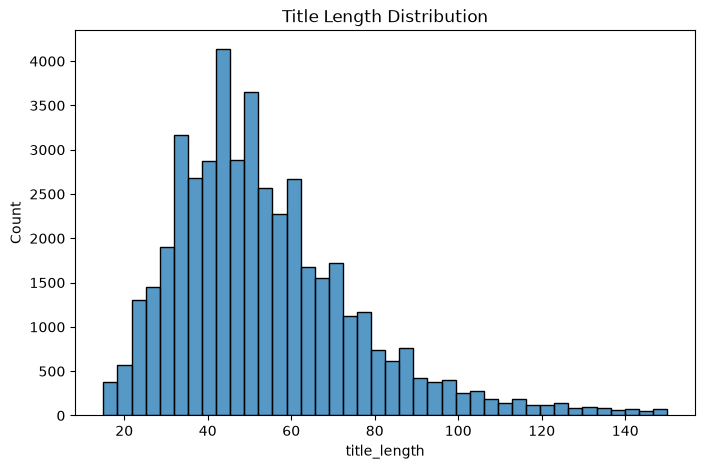

In [11]:
# distribution of title length

plt.figure(figsize=(8,5))

sns.histplot(df["title_length"], bins=40)

plt.title("Title Length Distribution")

plt.show()

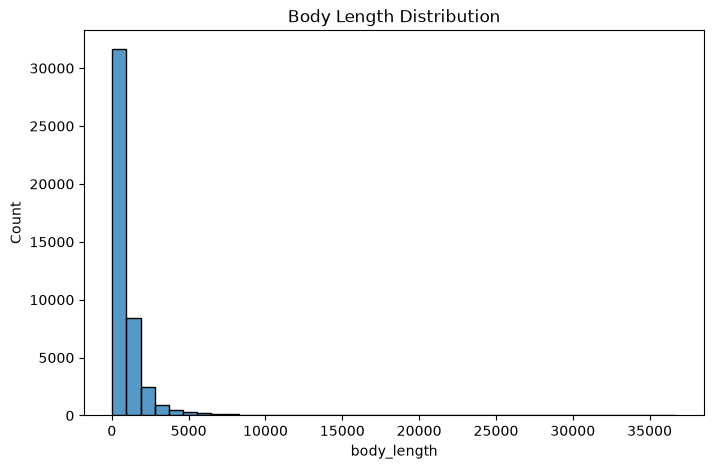

In [12]:
# distribution of body length

plt.figure(figsize=(8,5))

sns.histplot(df["body_length"], bins=40)

plt.title("Body Length Distribution")

plt.show()

In [13]:
# average length by label

df.groupby("Y")[["title_length","body_length"]].mean()

,title_length,body_length
Y,,
HQ,54.909067,1131.308000
LQ_CLOSE,51.100600,793.456133
LQ_EDIT,55.329400,1042.432067


# 3. Data Preprocessing

In [14]:
df["text"] = (
    df["Title"].fillna("") + " " +
    df["Body"].fillna("") + " " +
    df["Tags"].fillna("")
)

In [16]:
df = df[["text", "Y"]]

df.head()

,text,Y
0,Java: Repeat Task Every Random Seconds <p>I'm ...,LQ_CLOSE
1,Why are Java Optionals immutable? <p>I'd like ...,HQ
2,Text Overlay Image with Darkened Opacity React...,HQ
3,Why ternary operator in swift is so picky? <p>...,HQ
4,hide/show fab with scale animation <p>I'm usin...,HQ


In [17]:
# defining text cleaning function

import re
import string

def clean_text(text):

    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [18]:
# apply cleaning

df["clean_text"] = df["text"].apply(clean_text)

In [19]:
# preview once

df.head()

,text,Y,clean_text
0,Java: Repeat Task Every Random Seconds <p>I'm ...,LQ_CLOSE,java repeat task every random seconds im alrea...
1,Why are Java Optionals immutable? <p>I'd like ...,HQ,why are java optionals immutable id like to un...
2,Text Overlay Image with Darkened Opacity React...,HQ,text overlay image with darkened opacity react...
3,Why ternary operator in swift is so picky? <p>...,HQ,why ternary operator in swift is so picky the ...
4,hide/show fab with scale animation <p>I'm usin...,HQ,hideshow fab with scale animation im using cus...


In [20]:
# Train test split

from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(36000,)
(9000,)


# 4. Feature Engineering

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    strip_accents="unicode",
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 5. Baseline Model
## Multinomial Naive Bayes

In [22]:
from sklearn.naive_bayes import MultinomialNB

baseline_model = MultinomialNB()

baseline_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[12000.,12000.,12000.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.1,-1.1,-1.1]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['HQ','LQ_CLOSE','LQ_EDIT']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 20000)","[[ 4.62, 0. , 0.2 ,..., 1.47, 0.11, 0.8 ], [ 8.76, 0.3 , 2.06,..., 0. , 0.99, 0. ], [11.79, 1.61, 2.85,..., 0.31, 1.77, 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 20000)","[[ -9.68,-11.4 ,-11.22,...,-10.5 ,-11.3 ,-10.81], [ -9.03,-11.05,-10.19,...,-11.31,-10.62,-11.31], [ -8.78,-10.37, -9.98,...,-11.06,-10.31,-11.33]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20000


In [23]:
# predictions

baseline_pred = baseline_model.predict(X_test_tfidf)

In [24]:
# evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print(f"Accuracy : {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Precision: {precision_score(y_test, baseline_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, baseline_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, baseline_pred, average='weighted'):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, baseline_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, baseline_pred))

Accuracy : 0.6683
Precision: 0.6652
Recall   : 0.6683
F1 Score : 0.6652

Classification Report

              precision    recall  f1-score   support

          HQ       0.73      0.82      0.77      3000
    LQ_CLOSE       0.60      0.59      0.60      3000
     LQ_EDIT       0.66      0.59      0.63      3000

    accuracy                           0.67      9000
   macro avg       0.67      0.67      0.67      9000
weighted avg       0.67      0.67      0.67      9000


Confusion Matrix

[[2462  356  182]
 [ 510 1769  721]
 [ 398  818 1784]]


## Training Logistic Regression 

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=2.0,
    max_iter=2000,
    solver="saga",
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

/Users/dheerajalamuri/Documents/GitHub/Web-development/kpmg-ml-assignment/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [29]:
# evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print(f"Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, lr_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, lr_pred, average='weighted'):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, lr_pred))

Accuracy : 0.6917
Precision: 0.6894
Recall   : 0.6917
F1 Score : 0.6903

Classification Report

              precision    recall  f1-score   support

          HQ       0.78      0.81      0.80      3000
    LQ_CLOSE       0.62      0.59      0.60      3000
     LQ_EDIT       0.66      0.67      0.67      3000

    accuracy                           0.69      9000
   macro avg       0.69      0.69      0.69      9000
weighted avg       0.69      0.69      0.69      9000


Confusion Matrix

[[2442  366  192]
 [ 404 1764  832]
 [ 268  713 2019]]


## Model Comparison

In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, average="weighted"),
        precision_score(y_test, lr_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, average="weighted"),
        recall_score(y_test, lr_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, baseline_pred, average="weighted"),
        f1_score(y_test, lr_pred, average="weighted")
    ]
})

comparison.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.691667,0.689387,0.691667,0.690278
0,Multinomial Naive Bayes,0.668333,0.665196,0.668333,0.665239


## Final Model Selection

Two models were evaluated.

Logistic Regression achieved a higher F1-score while maintaining the best precision, recall and overall accuracy.

Multinomial Naive Bayes was also evaluated but did not outperform the above model with respect to any metric.

Therefore, Logistic Regression was selected as the final production model.

# Save Model

In [36]:
import joblib

joblib.dump(lr_model, "../models/doubt_triage_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
